In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fit_literature import load_data, find_nearest
from attenuation_curves import Att_Curve_2param, Li_08_fit_noratio
import ast

In [8]:
# Load the results from the CSV file
df = pd.read_csv("../data/galaxy_optimization_results.csv")

# Display the first few rows of the dataframe
df.head()

,gal_id,los,popt_2par,popt_4par,rmse_2par,rmse_4par,success_2par,success_4par
0,524576.0,28.0,[3.10691073 0.28572879],[-1.31414011e+02 2.11700183e+00 2.88624366e+...,0.056120,0.049480,True,True
1,524576.0,4.0,[10.87124965 -0.6310909 ],[ 8.83089453e+02 -2.03031809e+00 2.40908142e+...,0.692568,0.202755,True,True
2,524576.0,35.0,[2.71503088 0.01499929],[1.03470538e+02 1.06318786e+01 1.23909991e+02 ...,0.050530,0.043645,True,True
3,524576.0,19.0,[ 3.64327762 -0.03952779],[8.27278523e+02 1.20775544e+01 1.16588696e+03 ...,0.072153,0.051383,True,True
4,683079.0,39.0,[ 8.7319543 -0.65793098],[ 1.17742227e+02 -1.87127124e+00 8.14950398e+...,0.369736,0.236951,True,True


Plot the distribution of RMSE for 2-parameter and 4-parameter fits

Total RMSE for 2-parameter fit: 0.5683470508065681
Total RMSE for 4-parameter fit: 0.19709283531619642


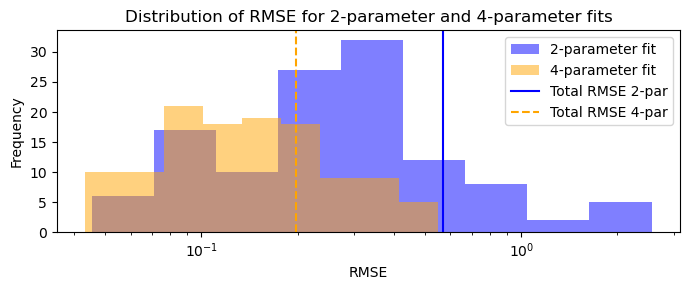

In [64]:
fig, ax = plt.subplots(figsize=(7, 3))
bins = np.logspace(np.log10(df['rmse_2par'].min()), np.log10(df['rmse_2par'].max()), num=10)
ax.hist(df['rmse_2par'], bins=bins, alpha=0.5, label='2-parameter fit', color='blue')
bins = np.logspace(np.log10(df['rmse_4par'].min()), np.log10(df['rmse_4par'].max()), num=10)
ax.hist(df['rmse_4par'], bins=bins, alpha=0.5, label='4-parameter fit', color='orange')

# Get aggregated RMSE. Each galaxy should have the same lambdas
total_rmse_2par = np.sqrt(np.mean(df['rmse_2par'] ** 2))
ax.axvline(total_rmse_2par, color='blue', linestyle='-', label='Total RMSE 2-par')
total_rmse_4par = np.sqrt(np.mean(df['rmse_4par'] ** 2))
ax.axvline(total_rmse_4par, color='orange', linestyle='--', label='Total RMSE 4-par')
print(f"Total RMSE for 2-parameter fit: {total_rmse_2par}")
print(f"Total RMSE for 4-parameter fit: {total_rmse_4par}")

ax.set_xlabel('RMSE')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of RMSE for 2-parameter and 4-parameter fits')
ax.legend()
ax.set_xscale('log')
fig.tight_layout()

Plot some example curves

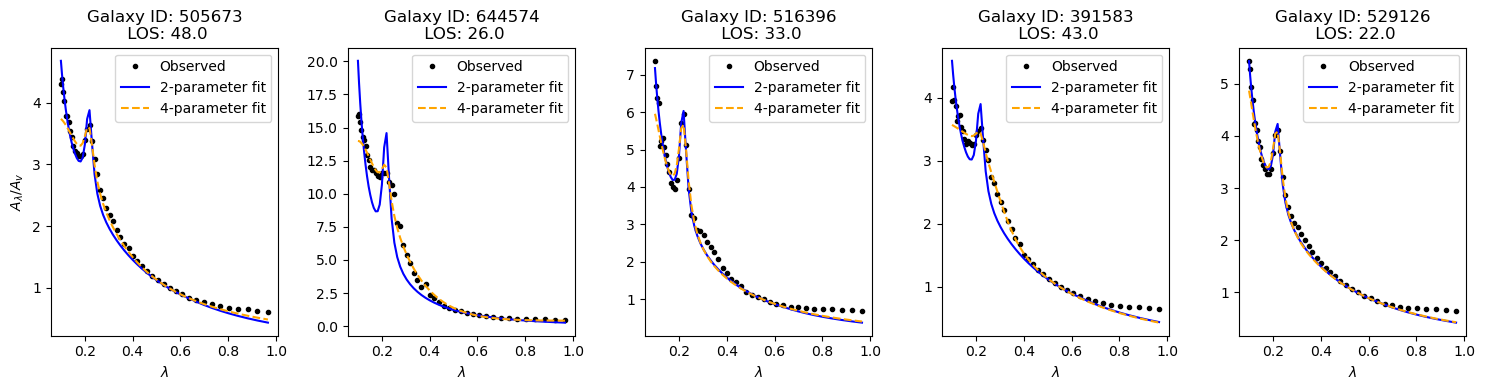

In [67]:
ngal = 5
ids, att_groups, attenuation_cols, lam_arr = load_data('../data/gal_los_iobcomp_attcurve_galprop.dat')

# Randomly select ngal galaxies from df['gal_id']
selected_ids = np.random.choice(df['gal_id'].unique(), size=ngal, replace=False)

def string_to_list(s):
    """
    Convert a string representation of a list to an actual list.
    """
    # Remove brackets and convert
    cleaned = s.strip('[]')
    return np.fromstring(cleaned, sep=' ').tolist()

fig, axs = plt.subplots(1, ngal, figsize=(3 * ngal, 4), sharex=True)

for ax, gal_id in zip(axs, selected_ids):
    group = att_groups.get_group(gal_id)

    # Randomly select a los
    los = group['los'].values
    los_idx = np.random.choice(len(los))
    los = los[los_idx]

    # Get the attenuation values for the selected los
    row = group[group['los'] == los]
    Alam_arr_cut = row[attenuation_cols].values.flatten()

    ### Normalising ad A_lambda to Av
    v_index = find_nearest(lam_arr,0.551)
    Av = Alam_arr_cut[v_index]
    Alam_Av_arr_cut = Alam_arr_cut/Av
    lam_cut = lam_arr[lam_arr < 1.]

    # Get the parameetrs for the 2-parameter and 4-parameter fits for this galaxy and los
    # Must convert to list
    group = df[df['gal_id'] == gal_id]
    row = group[group['los'] == los]
    popt_2par = string_to_list(row['popt_2par'].values.flatten()[0])
    popt_4par = string_to_list(row['popt_4par'].values.flatten()[0])
    rmse_2par = row['rmse_2par'].values.flatten().tolist()
    rmse_4par = row['rmse_4par'].values.flatten().tolist()
    fit_4par = Li_08_fit_noratio(lam_cut, *popt_4par)
    fit_2par = Att_Curve_2param(1e4*lam_cut, *popt_2par)
    rmse = np.sqrt(np.mean((Alam_Av_arr_cut - fit_2par) ** 2))
    assert np.isclose(rmse, rmse_2par), f"RMSE mismatch for 2-parameter fit: {rmse} vs {rmse_2par}"
    m = lam_cut>0.12
    rmse = np.sqrt(np.mean((Alam_Av_arr_cut[m] - fit_4par[m]) ** 2))
    assert np.isclose(rmse, rmse_4par), f"RMSE mismatch for 4-parameter fit: {rmse} vs {rmse_4par}"

    # Plot the results
    ax.plot(lam_cut, Alam_Av_arr_cut, 'o', label='Observed', markersize=3, color='k')
    ax.plot(lam_cut, fit_2par, label='2-parameter fit', color='blue', ls='-')
    ax.plot(lam_cut, fit_4par, label='4-parameter fit', color='orange', ls='--')
    ax.set_title(f'Galaxy ID: {int(gal_id)}\n LOS: {los}')
    ax.legend()
    ax.set_xlabel(r'$\lambda$')
axs[0].set_ylabel(r'$A_\lambda / A_v$')
fig.tight_layout()